# AR Model Notebook

1. **Setup** - Import packages and write function
2. **Simulation 1** - Generating synthetic AR(1) data and checking stationarity
3. **Model 1: AR(1) on Synthetic Data** - Basically taken line-for-line from the Stan documentation
4. **Simulation 2** - Generating 5 series of AR(1) data that is generated from a CAR model as described in the Stan documentation.
5. **Model 2: Hierarchical AR (ICAR Prior) on Synthetic Data** - Fitting `ar_1_hierarchical_icar.stan`
6. **Load CTA Data for Stan** - Loading in data, adjacency matrix, etc.
7. **Model 3: Hierarchical AR (ICAR Prior) on CTA Data** - Fitting `ar_1_hierarchical_icar.stan`
8. **Model 4: Hierarchical AR (ICAR Prior) on CTA Data with Seasonality** - Fitting `ar_1_hier_icar_seas.stan`
9. **Posterior Predictive Checks** - Checking whether the estimated DGP fits the actual data

---
## 1. Setup

In [ ]:
# Import Python packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Import Stan
from cmdstanpy import CmdStanModel, set_cmdstan_path
from cmdstanpy import from_csv
set_cmdstan_path("/deac/sta/classes/sta720/software/cmdstan/2.37.0")

In [ ]:
# load station look-up data frame
station_lookup = pd.read_csv("../../data/clean/station-lookup.csv")

# Function to look-up stations
def lookup_station(value, station_lookup):
    """Look up a CTA station by ID or name. Accepts a scalar or iterable."""
    id_to_name = dict(zip(station_lookup["station_id"], station_lookup["stationname"]))
    name_to_id = dict(zip(station_lookup["stationname"], station_lookup["station_id"]))
    
    def lookup_one(v):
        if isinstance(v, (int, np.integer)):
            return id_to_name.get(v)
        return name_to_id.get(v)
    
    if isinstance(value, (int, str, np.integer)):
        return lookup_one(value)
    
    return [lookup_one(v) for v in value]

In [ ]:
# Function to simulate AR(1) univariate data
def sim_ar_model(alpha, beta, sigma, T, initial=0, seed=None):
    np.random.seed(seed)
    assert T >= 1

    Y = np.zeros(T)
    epsilon = np.random.normal(0, sigma, size=T)

    Y[0] = initial

    for t in range(1, T):
        Y[t] = alpha + beta * Y[t - 1] + epsilon[t]
    return Y

## 2. Simulate AR(1) Data

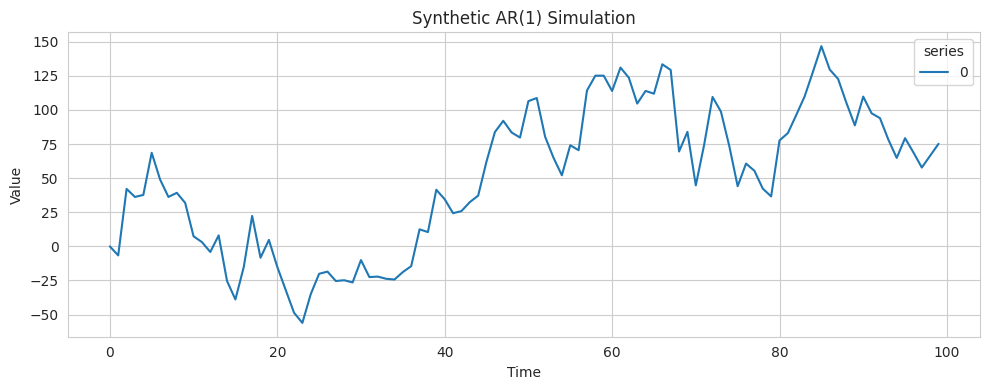

In [ ]:
# Simulate data and plot
T = 100
alpha = 0
beta= 0.98
sigma = 20

y = sim_ar_model(alpha = alpha, beta = beta, sigma = 20, T = T, seed = 5)

df_sim = pd.DataFrame(y)
df_sim["t"] = range(T)
df_sim_long = df_sim.melt(id_vars="t", var_name="series", value_name="value")

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_sim_long, x="t", y="value", hue="series")
plt.title("Synthetic AR(1) Simulation")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 3. Model 1: AR(1) on Simulated Data

In [ ]:
# Run simple stan model (from documentation)
stan_data_ar1_sim = {
    "T": T,
    "y": y
}

ar_mod = CmdStanModel(stan_file="ar_1.stan")
ar_mod_post = ar_mod.sample(data=stan_data_ar1_sim)
print(ar_mod_post.diagnose())

20:26:33 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

20:26:33 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### 3.1 Parameter Recovery

In [ ]:
# Recover parameters
ar_mod_params = ar_mod_post.stan_variables()

print("True alpha:", alpha)
print("Estimated alpha:", ar_mod_params["alpha"].mean(axis=0))
print()
print("True sigma:", sigma)
print("Estimated sigma:", ar_mod_params["sigma"].mean(axis=0))
print()
print("True sigma:", sigma)
print("Estimated sigma:", ar_mod_params["sigma"].mean(axis=0))

True alpha: 0
Estimated alpha: 4.121858106797783

True sigma: 20
Estimated sigma: 18.992660614000002

True sigma: 20
Estimated sigma: 18.992660614000002


In [8]:
print(ar_mod_post.summary())

             Mean      MCSE    StdDev       MAD          5%         50%  \
lp__  -337.107000  0.029282  1.225980  1.000580 -339.442000 -336.775000   
alpha    4.121860  0.054940  2.689610  2.665770   -0.334417    4.155950   
beta     0.933633  0.000732  0.036153  0.035665    0.874568    0.933734   
sigma   18.992700  0.027115  1.356180  1.312570   16.889400   18.932400   

              95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
lp__  -335.764000   1940.59   2365.16     5952.74  1.00204  
alpha    8.535760   2410.76   2503.33     7394.98  1.00165  
beta     0.993486   2451.84   2583.24     7520.98  1.00136  
sigma   21.361700   2542.48   2637.54     7799.03  1.00118  


## 4. Simulate Network AR(1) Data

In [ ]:
# Simulate independent AR(1) data function
def sim_ar_net_model(c, beta, T, initial=None, seed=None):
    if seed is not None:
        np.random.seed(seed)
    K = len(c)
    Y = np.zeros((T, K))
    if initial is not None:
        Y[0] = initial
    else:
        Y[0] = c / (1 - beta) # Start at stationary mean
    
    for t in range(1, T):
        epsilon = np.random.normal(0, 1, K)  # independent innovations
        Y[t] = c + beta * Y[t-1] + epsilon
    
    return Y


In [71]:
# Simulation parameters
K = 5
c_net = np.array([0.7, 0.05, 0.6, 0.12, 0.5])       # all node-level intercepts
beta_net = np.array([-0.45, -0.40, -0.30, -0.25, -0.18])   # all node-level coefficients
gamma_net = c_net.mean()                             # population intercept (hierarchical mean)
delta_net = beta_net.mean()                          # population AR coefficient (hierarchical mean)
T_net = 200

Y_net = sim_ar_net_model(c=c_net, beta=beta_net, T=T_net, seed=42)

print(gamma_net)
print(delta_net)

0.394
-0.316


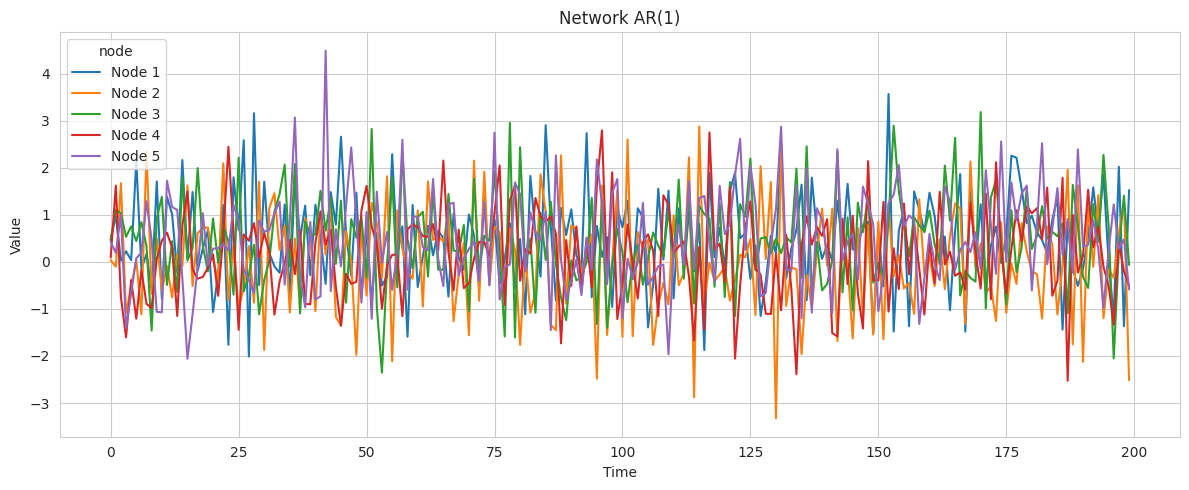

In [72]:
# Plot all 5 nodes
df_net = pd.DataFrame(Y_net, columns=[f"Node {i+1}" for i in range(K)])
df_net["t"] = range(T_net)
df_net_long = df_net.melt(id_vars="t", var_name="node", value_name="value")

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_net_long, x="t", y="value", hue="node")
plt.title("Network AR(1)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 5. Model 2: Hierarchical AR(1) with ICAR Prior on Simulated Network Data

In [ ]:
node1 = []
node2 = []

# Set-up adjacency matrix
W = np.zeros((K, K))
for i in range(K - 1):
    W[i, i + 1] = 1
    W[i + 1, i] = 1

# Split up adjacency matrix into vectors
for i in range(K):
    for j in range(i + 1, K):
        if W[i, j] == 1:
            node1.append(i + 1)
            node2.append(j + 1)

print(node1)
print(node2)

# stan data
stan_data_icar = {
    "T": T_net,
    "K": K,
    "Y": Y_net,
    "N_edges": N_edges,
    "node1": node1,
    "node2": node2
}

Number of edges: 4
Edge list: [(1, 2), (2, 3), (3, 4), (4, 5)]
[1, 2, 3, 4]
[2, 3, 4, 5]


In [ ]:
# Run to re-sample
ar_mod_icar = CmdStanModel(stan_file="ar_1_hierarchical_icar.stan")
ar_mod_icar_post = ar_mod_icar.sample(data=stan_data_icar)
print(ar_mod_icar_post.diagnose())

22:18:19 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

22:19:50 - cmdstanpy - INFO - CmdStan done processing.
22:19:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Consider re-running with show_console=True if the above output is unclear!
22:19:50 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 551 iterations at max treedepth (55.1%)
	Chain 2 had 467 iterations at max treedepth (46.7%)
	Chain 3 had 530 iterations at max treedepth (53.0%)
	Chain 4 had 327 iterations at max treedepth (32.7%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



Checking sampler transitions treedepth.
1877 of 4000 (46.92%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



In [ ]:
# Load model
ar_mod_icar_post = from_csv('./ar_mod_icar_post_output')
print(ar_mod_icar_post.diagnose())

01:27:17 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 551 iterations at max treedepth (55.1%)
	Chain 2 had 467 iterations at max treedepth (46.7%)
	Chain 3 had 530 iterations at max treedepth (53.0%)
	Chain 4 had 327 iterations at max treedepth (32.7%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


### 5.1 Parameter Recovery

In [75]:
ar_mod_icar_params = ar_mod_icar_post.stan_variables()

print("True gamma (pop intercept):", gamma_net)
print("Estimated gamma:", ar_mod_icar_params["gamma"].mean(axis=0))

print("True delta (pop coefficient):", delta_net)
print("Estimated delta:", ar_mod_icar_params["delta"].mean(axis=0))

print("True c (node intercepts):", c_net)
print("Estimated c:", ar_mod_icar_params["c"].mean(axis=0))

print("True beta (node coefficients):", beta_net)
print("Estimated beta:", ar_mod_icar_params["beta"].mean(axis=0))


True gamma (pop intercept): 0.394
Estimated gamma: 0.38456898820445745
True delta (pop coefficient): -0.316
Estimated delta: -0.28023020851499997
True c (node intercepts): [0.7  0.05 0.6  0.12 0.5 ]
Estimated c: [0.6575449  0.03801128 0.5796697  0.17954089 0.52404712]
True beta (node coefficients): [-0.45 -0.4  -0.3  -0.25 -0.18]
Estimated beta: [-0.41348342 -0.48120788 -0.29433115 -0.10427218 -0.10784294]


In [76]:
print(ar_mod_icar_post.summary())

                   Mean      MCSE    StdDev       MAD          5%         50%  \
lp__        -488.306000  0.111835  3.599510  3.544460 -494.735000 -487.989000   
gamma          0.384569  0.005442  0.197514  0.157610    0.077408    0.383175   
c_zero[1]      0.818125  0.014322  0.579751  0.555674   -0.102018    0.789022   
c_zero[2]     -1.047790  0.016417  0.632824  0.641311   -2.161450   -1.014420   
c_zero[3]      0.581571  0.013375  0.544123  0.542914   -0.271816    0.565062   
c_zero[4]     -0.621244  0.013544  0.541663  0.531007   -1.560320   -0.593329   
c_zero[5]      0.415880  0.012633  0.523390  0.519616   -0.428324    0.398803   
sigma_c        0.395228  0.005267  0.196771  0.144164    0.185797    0.344826   
delta         -0.280230  0.000428  0.028702  0.028696   -0.326998   -0.280363   
phi_zero[1]   -0.810153  0.014368  0.502830  0.447951   -1.785910   -0.716495   
phi_zero[2]   -1.152540  0.012994  0.463849  0.447795   -1.992430   -1.096480   
phi_zero[3]   -0.079014  0.0

## 6. Load CTA Data for Stan

In [ ]:
# Read cleaned data
cta_wide = pd.read_csv("../../data/clean/cta-data-wide.csv")
cta_adj = pd.read_csv("../../data/clean/cta-adjacency.csv")

# Extract Y matrix (station columns only)
station_cols = [c for c in cta_wide.columns if c.startswith("s_")]
Y_cta = cta_wide[station_cols].values

T_cta = Y_cta.shape[0]
K_cta = Y_cta.shape[1]

In [ ]:
# Build edge vectors from adjacency matrix
adj_ids = cta_adj["station_id"].astype(str).values
W_cta = cta_adj.drop(columns="station_id").values

node1_cta = []
node2_cta = []
for i in range(K_cta):
    for j in range(i + 1, K_cta):
        if W_cta[i, j] == 1:
            node1_cta.append(i + 1)
            node2_cta.append(j + 1)

N_edges_cta = len(node1_cta)

In [10]:
stan_data_cta = {
    "T": T_cta,
    "K": K_cta,
    "Y": Y_cta,
    "N_edges": N_edges_cta,
    "node1": node1_cta,
    "node2": node2_cta,
}

print(N_edges_cta)

Y shape: 208 weeks x 138 stations
Edges: 142
NAs in Y: 0


## 7. Model 3: CTA data on AR(1) Hierarchical ICAR Model

In [ ]:
# Run to re-sample
ar_mod_cta_icar = CmdStanModel(stan_file="ar_1_hierarchical_icar.stan")
ar_mod_cta_icar_post = ar_mod_cta_icar.sample(data=stan_data_cta)
print(ar_mod_cta_icar_post.diagnose())
ar_mod_cta_icar_post.save_csvfiles(dir='./ar_mod_cta_icar_output')

00:22:14 - cmdstanpy - INFO - compiling stan file /deac/sta/classes/sta720-sp-2026/hatan25/sta720-project/notebooks/ar/ar_1_hierarchical_icar.stan to exe file /deac/sta/classes/sta720-sp-2026/hatan25/sta720-project/notebooks/ar/ar_1_hierarchical_icar
00:22:37 - cmdstanpy - INFO - compiled model executable: /deac/sta/classes/sta720-sp-2026/hatan25/sta720-project/notebooks/ar/ar_1_hierarchical_icar
00:22:37 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

00:38:15 - cmdstanpy - INFO - CmdStan done processing.
00:38:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Consider re-running with show_console=True if the above output is unclear!



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [ ]:
# Load model
ar_mod_cta_icar_post = from_csv('./ar_mod_cta_icar_output')
print(ar_mod_cta_icar_post.diagnose())

In [ ]:
# Load posterior samples
draws = ar_mod_cta_icar_post.stan_variables()
draws_df = ar_mod_cta_icar_post.draws_pd()
draws_array = ar_mod_cta_icar_post.draws()

gamma = draws['gamma']
delta = draws['delta']

# posterior estimates for gamma, delta, and sigma_phi
print(f"gamma: {gamma.mean():.3f} [{np.quantile(gamma, 0.025):.3f}, {np.quantile(gamma, 0.975):.3f}]")
print(f"delta: {delta.mean():.3f} [{np.quantile(delta, 0.025):.3f}, {np.quantile(delta, 0.975):.3f}]")

gamma: 0.003 [0.002, 0.004]
delta: -0.262 [-0.273, -0.251]


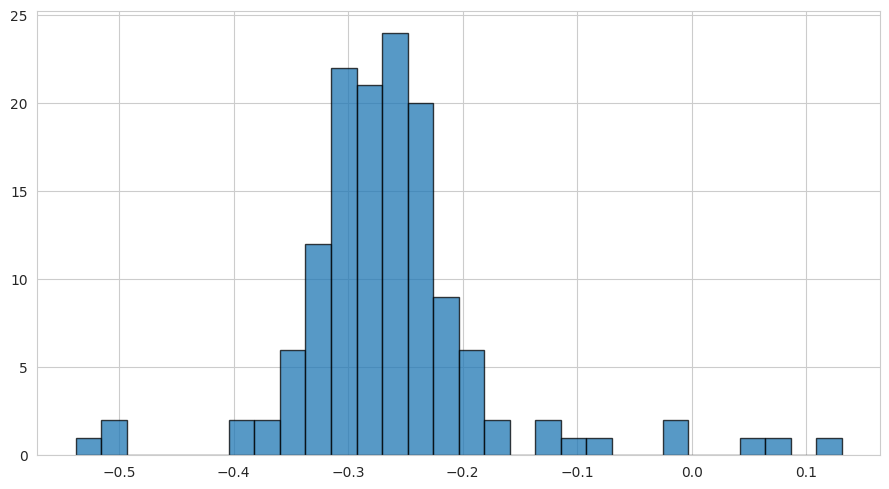

In [ ]:
# Histogram for station-level betas
beta = draws['beta']     
beta_median = np.median(beta, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(beta_median, bins=30, edgecolor='black', alpha=0.75)
plt.tight_layout()
plt.show()

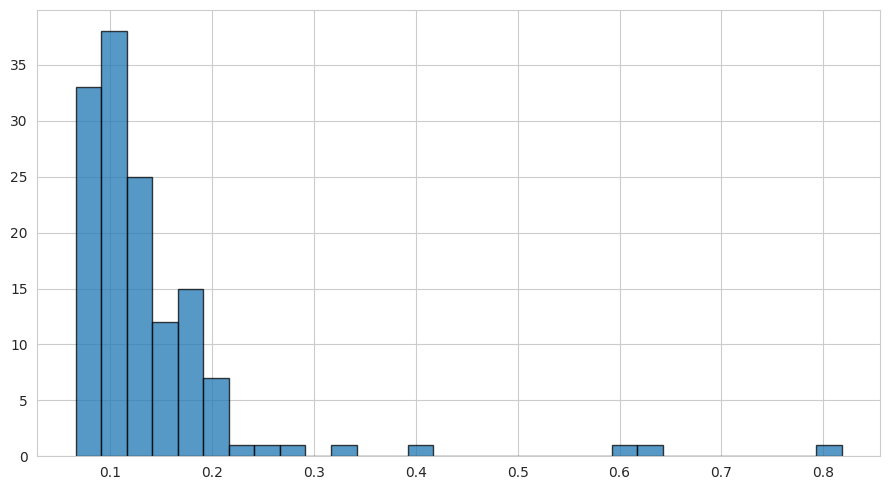

In [ ]:
# Histogram for station-level sigmas
sigma = draws['sigma']        
sigma_median = np.median(sigma, axis=0) 

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sigma_median, bins=30, edgecolor='black', alpha=0.75)
plt.tight_layout()
plt.show()

In [ ]:
station_id = cta_adj["station_id"]

station_df = pd.concat([station_id, pd.Series(beta_median, name='beta_median'), pd.Series(sigma_median, name='sigma_median')], axis=1)
print(station_df)

# Look-up stations from looking at the histogram
station_select = station_df.loc[(station_df['beta_median'] < -0.325) & (station_df['beta_median'] > -0.45)]["station_id"]
print(station_select)

lookup_station(station_select, station_lookup)

     station_id  beta_median  sigma_median
0         40010    -0.288313      0.112092
1         40020    -0.257758      0.083607
2         40030    -0.309658      0.081971
3         40040    -0.308145      0.172978
4         40050    -0.203668      0.104096
..          ...          ...           ...
133       41660    -0.288354      0.102721
134       41670    -0.316079      0.087973
135       41680    -0.020275      0.326886
136       41690    -0.286795      0.269500
137       41700    -0.239648      0.097355

[138 rows x 3 columns]
7      40080
11     40130
13     40150
21     40240
24     40280
35     40420
38     40450
41     40480
52     40600
60     40700
81     40930
82     40960
94     41080
107    41230
109    41250
111    41270
125    41430
Name: station_id, dtype: int64


['Sheridan',
 '51st',
 'Pulaski-Cermak',
 '79th',
 'Central-Lake',
 'Cicero-Cermak',
 '95th/Dan Ryan',
 'Cicero-Lake',
 'Kostner',
 'Laramie',
 'Midway Airport',
 'Pulaski-Orange',
 '47th-South Elevated',
 '47th-Dan Ryan',
 'Central-Evanston',
 '43rd',
 '87th']

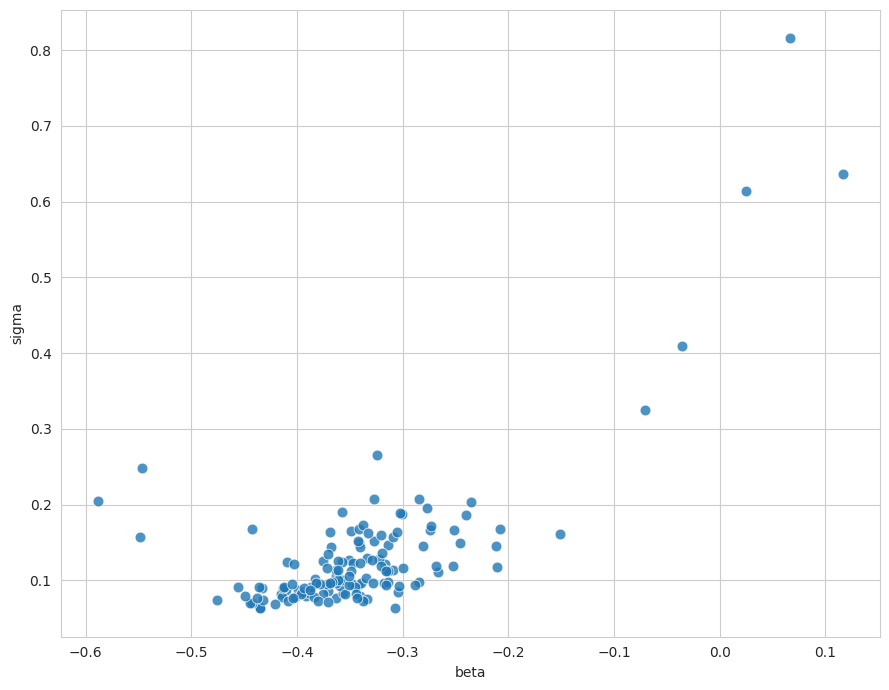

In [ ]:
# Scatter plot of betas vs sigmas
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(
    data=station_df,
    x='beta_median',
    y='sigma_median',
    s=60,
    alpha=0.8,
    ax=ax,
)

ax.set_xlabel('beta')
ax.set_ylabel('sigma')

plt.tight_layout()
plt.show()

## 8. Model 4: CTA data on AR(1) Hierarchical ICAR Model with Seasonality

In [ ]:
# Seasonal data
seas_cols = [c for c in cta_wide.columns if c.startswith("mon")]
X_cta = cta_wide[seas_cols].values

P_cta = X_cta.shape[1]

In [86]:
stan_data_cta_seas = {
    "T": T_cta,
    "K": K_cta,
    "Y": Y_cta,
    "P": P_cta,
    "X": X_cta,
    "N_edges": N_edges_cta,
    "node1": node1_cta,
    "node2": node2_cta,
}

In [ ]:
# Run to re-sample
ar_mod_cta_icar_seas = CmdStanModel(stan_file="ar_1_hier_icar_seas.stan")
mod_final = ar_mod_cta_icar_seas.sample(data=stan_data_cta_seas)
print(ar_mod_final.diagnose())
mod_final.save_csvfiles(dir='./ar_mod_cta_icar_seas_output')

In [ ]:
# Load model
ar_mod_final = from_csv('./ar_mod_cta_icar_seas_output')
print(ar_mod_final.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [ ]:
# Print gamma and delta posterior means

draws = ar_mod_final.stan_variables()
draws_df = ar_mod_final.draws_pd()
draws_array = ar_mod_final.draws()

gamma = draws['gamma']
delta = draws['delta']

print(f"gamma: {gamma.mean():.3f} [{np.quantile(gamma, 0.025):.3f}, {np.quantile(gamma, 0.975):.3f}]")
print(f"delta: {delta.mean():.3f} [{np.quantile(delta, 0.025):.3f}, {np.quantile(delta, 0.975):.3f}]")

gamma: 0.064 [0.060, 0.069]
delta: -0.340 [-0.351, -0.328]


In [ ]:
# Print seasonal coefficient posterior medians

seas = draws['seas']
print("Posterior medians:")
for i, m in enumerate(np.median(seas, axis=0)):
    print(f"  Month {i+2}: {m:+.3f}")  # Feb=2 through Dec=12 if January is baseline

Posterior medians:
  Month 2: -0.034
  Month 3: -0.055
  Month 4: -0.044
  Month 5: -0.052
  Month 6: -0.052
  Month 7: -0.042
  Month 8: -0.063
  Month 9: -0.049
  Month 10: -0.075
  Month 11: -0.113
  Month 12: -0.151


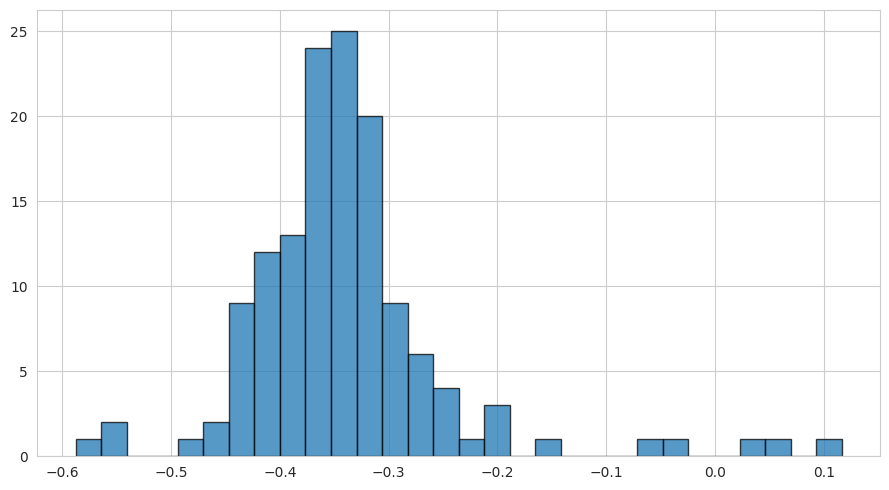

In [91]:
beta = draws['beta']          
beta_median = np.median(beta, axis=0) 

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(beta_median, bins=30, edgecolor='black', alpha=0.75)

plt.tight_layout()
plt.show()

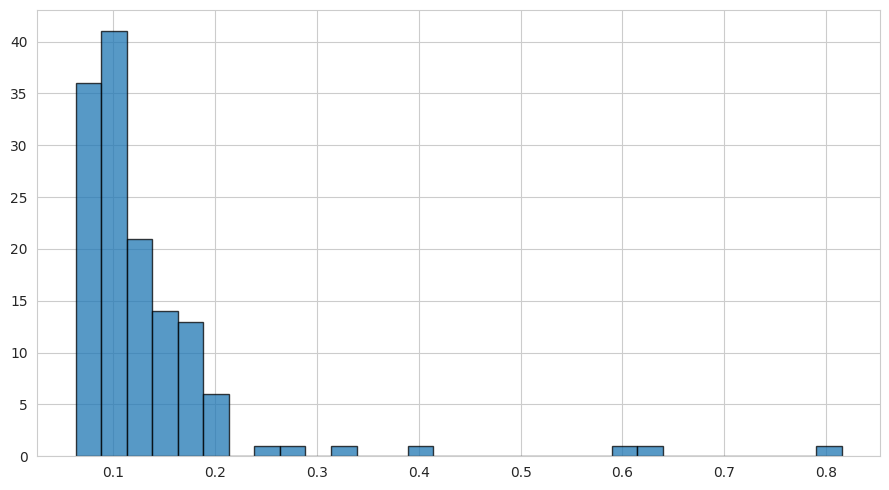

In [92]:
sigma = draws['sigma']               
sigma_median = np.median(sigma, axis=0)  

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sigma_median, bins=30, edgecolor='black', alpha=0.75)

plt.tight_layout()
plt.show()

In [53]:
station_df = pd.concat([station_id, pd.Series(beta_median, name='beta_median'), pd.Series(sigma_median, name='sigma_median')], axis=1)
print(station_df)

station_select = station_df.loc[(station_df['beta_median'] < -.1) & (station_df['beta_median'] > -.2)]["station_id"]
print(station_select)

lookup_station(station_select, station_lookup)

     station_id  beta_median  sigma_median
0         40010    -0.362860      0.105291
1         40020    -0.363188      0.076830
2         40030    -0.391175      0.079425
3         40040    -0.368890      0.163800
4         40050    -0.317743      0.096181
..          ...          ...           ...
133       41660    -0.368724      0.096712
134       41670    -0.387806      0.087507
135       41680    -0.070741      0.325310
136       41690    -0.324270      0.265913
137       41700    -0.303402      0.092123

[138 rows x 3 columns]
118    41340
Name: station_id, dtype: int64


['LaSalle']

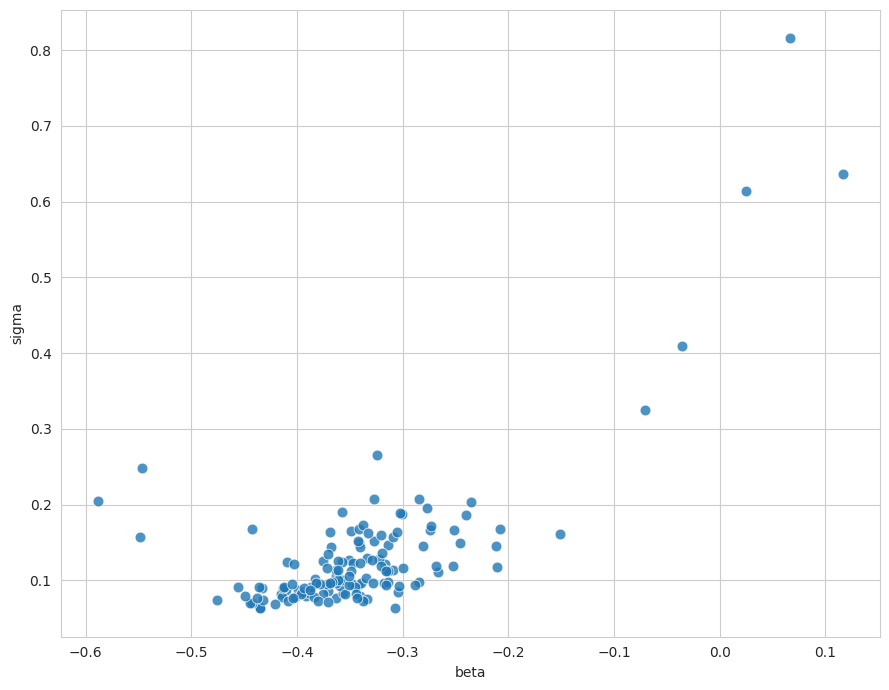

In [ ]:
# Scatter plot of betas vs sigmas
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(
    data=station_df,
    x='beta_median',
    y='sigma_median',
    s=60,
    alpha=0.8,
    ax=ax,
)

ax.set_xlabel('beta')
ax.set_ylabel('sigma')

plt.tight_layout()
plt.show()

## 9. Posterior Predictive Checks

In [ ]:
# Select stations for PPCs
station_select = ['Sox-35th-Dan Ryan', 'Clark/Lake', 'Loyola', 'LaSalle']
station_select_id = lookup_station(station_select, station_lookup)

check_idx = [
    np.where(cta_adj['station_id'].values == sid)[0][0] + 1
    for sid in station_select_id
]

print(check_idx)

[np.int64(18), np.int64(33), np.int64(115), np.int64(119)]


In [ ]:
# Generate quantities data and find the predicted values
gq_data = {
    "T": T_cta,
    "K": K_cta,
    "Y": Y_cta,
    "P": P_cta,
    "X": X_cta,
    "N_edges": N_edges_cta,
    "node1": node1_cta,
    "node2": node2_cta,
    "N_check": len(check_idx),
    "check_idx": check_idx
}

gq_model = CmdStanModel(stan_file='generate_quantities.stan')
gq_fit = gq_model.generate_quantities(data=gq_data, previous_fit=ar_mod_final)
y_rep = gq_fit.stan_variables()['y_rep']

22:15:07 - cmdstanpy - INFO - Chain [1] start processing
22:15:07 - cmdstanpy - INFO - Chain [2] start processing
22:15:07 - cmdstanpy - INFO - Chain [3] start processing
22:15:07 - cmdstanpy - INFO - Chain [4] start processing
22:15:08 - cmdstanpy - INFO - Chain [1] done processing
22:15:09 - cmdstanpy - INFO - Chain [3] done processing
22:15:09 - cmdstanpy - INFO - Chain [4] done processing
22:15:09 - cmdstanpy - INFO - Chain [2] done processing


In [ ]:
# Build data frame to export to R
ppc_records = []
for i, station in enumerate(station_select):
    k = check_idx[i] - 1
    median = np.median(y_rep[:, :, i], axis=0)
    lower = np.quantile(y_rep[:, :, i], 0.025, axis=0)
    upper = np.quantile(y_rep[:, :, i], 0.975, axis=0)
    observed = Y_cta[:, k]
    
    for t in range(T_cta):
        ppc_records.append({
            'station': station,
            'week': t,
            'observed': observed[t],
            'median': median[t],
            'lower': lower[t],
            'upper': upper[t],
        })

ppc_df = pd.DataFrame(ppc_records)
ppc_df.to_csv('../../data/clean/ppc_summary.csv', index=False)

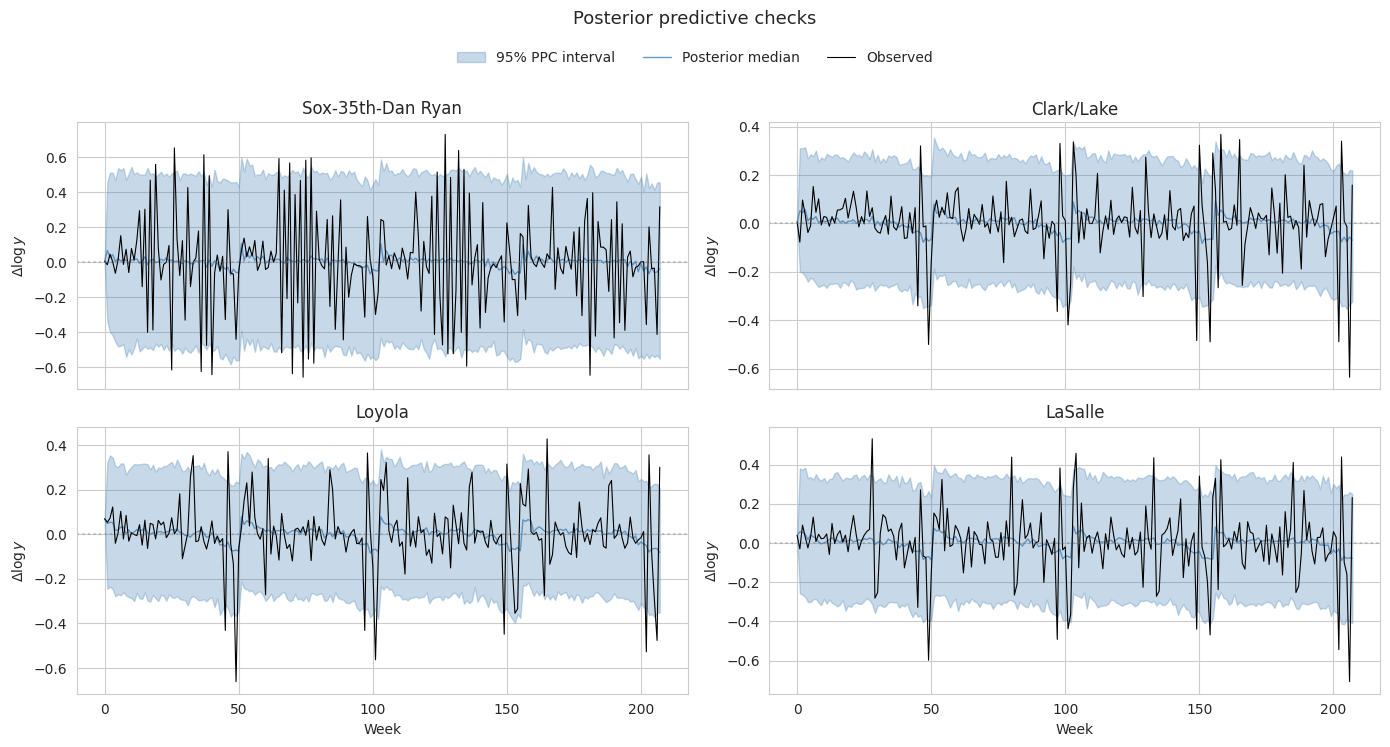

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
axes = axes.flatten()

handles, labels = None, None

for i in range(len(station_select)):
    ax = axes[i]
    k = check_idx[i] - 1

    median = np.median(y_rep[:, :, i], axis=0)
    lower = np.quantile(y_rep[:, :, i], 0.025, axis=0)
    upper = np.quantile(y_rep[:, :, i], 0.975, axis=0)

    ax.fill_between(range(T_cta), lower, upper, alpha=0.3, color='steelblue', label='95% PPC interval')
    ax.plot(median, color='steelblue', linewidth=1, alpha=0.8, label='Posterior median')
    ax.plot(Y_cta[:, k], color='black', linewidth=0.8, label='Observed')

    ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
    ax.set_title(station_select[i])
    ax.set_ylabel(r'$\Delta \log y$')

    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

axes[2].set_xlabel('Week')
axes[3].set_xlabel('Week')

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

fig.suptitle('Posterior predictive checks', y=1.06, fontsize=13)
plt.tight_layout()
plt.show()